# Multi-Frame Cell deformation Fourier analysis

In [3]:
import os
import glob
from skimage import io
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from skimage.color import rgb2gray
from skimage.filters import gaussian
from skimage.segmentation import active_contour
from fourier_functions import analyze_frame_fourier, track_droplet_template

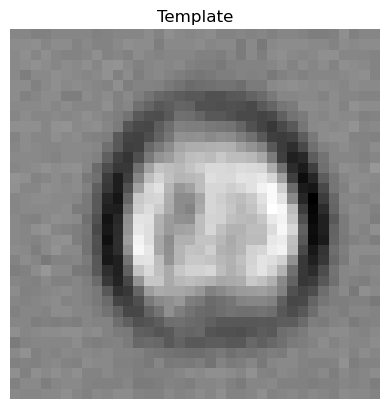

In [4]:
# ==========================================
# 1. INPUT PARAMETERS BY USER
# ==========================================
folder_path = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7'
format = '*.tif'

#image_path = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/cell0000002.tif'

first_frame = 500       
last_frame = 501
step = 2       

#Template informations
image_path_firstframe = '/Volumes/Elements/Rheoflu/Luca/20250918_cellTHP1Paolo_test1/20250918_CellTHP1_100w_60h_08muls_chirp/constriction7/constriction7011809.tif'
y_center = 97 
x_center = 139
radius = 18
gray_img1 = cv2.cvtColor(cv2.imread(image_path_firstframe), cv2.COLOR_BGR2GRAY)
template = gray_img1[int(y_center - radius) : int(y_center + radius), int(x_center - radius) : int(x_center + radius)]
plt.imshow(template, cmap='gray')
plt.title('Template')
plt.axis('off') # Nasconde gli assi
plt.show()

In [5]:
gray_img1.shape

(256, 256)

In [6]:
# ==========================================
# 2. DATA READING
# ==========================================
image_files = sorted(glob.glob(os.path.join(folder_path, format)))

if len(image_files) == 0:
    print(f"ERROR: No image found in {folder_path}")

KeyboardInterrupt: 

In [ ]:
if last_frame > len(image_files):
        last_frame = len(image_files)

diff = last_frame - first_frame
rest = diff % step

if rest != 0:
        print(f"⚠️ AVVISO: Il range di frame selezionato ({diff} frame) non è un multiplo dello step ({step}).")
        print(f"   Verranno saltati gli ultimi {rest} frame finali all'interno del range.\n")

selected_frames = image_files[first_frame:last_frame:step]

print(f"Trovate {len(image_files)} immagini totali.")
print(f"Verranno analizzati {len(selected_frames)} frame.\n")

NameError: name 'image_files' is not defined

In [ ]:
# ==========================================
# 3. IMAGES ANALYSIS
# ==========================================
av_radius_a0 = []
shift_ord1 = []
amp_ord2 = []
amp_ord3 = []
amp_ord4 = []
coeff_ord2 = []
coeff_ord3 = []
coeff_ord4 = []


# Definisci il contorno iniziale (init) per il primo frame
# (Aggiusta 100, 100 e 50 in base alle coordinate e al raggio della tua goccia!)
h_roi, w_roi = template.shape
radius_start = min(h_roi, w_roi) / 2 - 1
s = np.linspace(0, 2*np.pi, 400)    #points on a circle
x = h_roi//2 + radius_start * np.sin(s)            #points coordinates: h_roi//2 + radius * np.sin(s) 
y = w_roi//2 + radius_start * np.cos(s)            #                    w_roi//2 + radius * np.cos(s)
init = np.array([x, y]).T

for cicle_index, img_path in enumerate(selected_frames):
    file_name = os.path.basename(img_path)
    abolute_frame = first_frame + (cicle_index * step)
        
    print(f"► Analyning Frame {abolute_frame} ({file_name})...")
    img = io.imread(img_path)

    found, center, ROI, confidence = track_droplet_template(
        img, 
        template, 
        threshold=0.3, 
        plot_result=False #TRUE to visualize the tracking results
        )

    if found:
    # 1. Analisi del frame (sostituisci i parametri con quelli ottimali per i tuoi video)
        a0, a2, a3, a4, c1, c2, c3, c4, contour_estratto = analyze_frame_fourier_complete(
            img=ROI, 
        init_contour=init, 
        sigma=3,        # Cambia se serve un filtro gaussiano più o meno forte
        alpha=1.5,      # Tensione del contorno
        beta=10.0,      # Rigidità del contorno
        w_edge=7.0,     # Attrazione verso i bordi dell'immagine
        w_line=0.0,
        plot_profile=False, #TRUE to visualize the fit plot
        frame_number = abolute_frame
        )
    
        # 2. Salvataggio dei risultati per il frame corrente
        av_radius_a0.append(a0)
        coeff_ord2.append(a2)
        coeff_ord3.append(a3)
        coeff_ord4.append(a4)
        shift_ord1.append(c1)
        amp_ord2.append(c2)
        amp_ord3.append(c3)
        amp_ord4.append(c4)
    
            #init = contour_estratto #faster with this!
    else:
        print(f"⚠️ Frame {abolute_frame} saltato: goccia non trovata o troppo deformata! (confidenza: {confidence:.2f})")

    print("\n✅ Sequence completed")

► Analyning Frame 130 (Constrict_5000131.tif)...

✅ Sequence completed
► Analyning Frame 132 (Constrict_5000133.tif)...

✅ Sequence completed
► Analyning Frame 134 (Constrict_5000135.tif)...

✅ Sequence completed
► Analyning Frame 136 (Constrict_5000137.tif)...

✅ Sequence completed
► Analyning Frame 138 (Constrict_5000139.tif)...

✅ Sequence completed
► Analyning Frame 140 (Constrict_5000141.tif)...

✅ Sequence completed
► Analyning Frame 142 (Constrict_5000143.tif)...

✅ Sequence completed
► Analyning Frame 144 (Constrict_5000145.tif)...

✅ Sequence completed
► Analyning Frame 146 (Constrict_5000147.tif)...

✅ Sequence completed
► Analyning Frame 148 (Constrict_5000149.tif)...

✅ Sequence completed
► Analyning Frame 150 (Constrict_5000151.tif)...

✅ Sequence completed
► Analyning Frame 152 (Constrict_5000153.tif)...

✅ Sequence completed
► Analyning Frame 154 (Constrict_5000155.tif)...

✅ Sequence completed
► Analyning Frame 156 (Constrict_5000157.tif)...

✅ Sequence completed
► Anal

KeyboardInterrupt: 

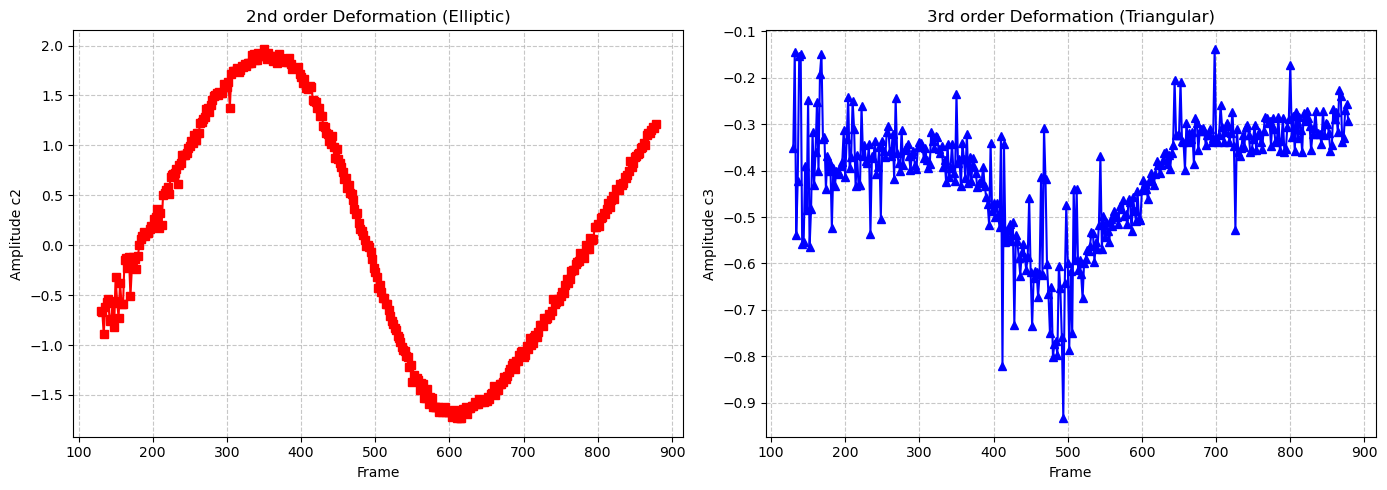

In [ ]:
# ----------------------------------------------------
# DEFORMATION-TIME PLOTS (a2 - a3)
# ----------------------------------------------------
asse_temporale = np.arange(first_frame, last_frame, step)
asse = asse_temporale[:len(amp_ord2)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(asse, coeff_ord2, marker='s', color='red')
ax1.set_xlabel('Frame')
ax1.set_ylabel('Amplitude c2')
ax1.set_title('2nd order Deformation (Elliptic)')
ax1.grid(True, linestyle='--', alpha=0.7)

ax2.plot(asse, coeff_ord3, marker='^', color='blue')
ax2.set_xlabel('Frame')
ax2.set_ylabel('Amplitude c3')
ax2.set_title('3rd order Deformation (Triangular)')
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()




In [ ]:
# ----------------------------------------------------
# BAR PLOTS FOR A2 AND A3 (ALL FRAMES)
# ----------------------------------------------------
"""
import math

num_frames = len(av_radius_a0)
cols = 5
rows = math.ceil(num_frames / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))

if num_frames > 1:
    axes = axes.flatten()
else:
    axes = [axes]
    
labels = ['a2\n(2nd harmonic)', 'a3\n(3rd harmonic)']

for i in range(num_frames):
    ax = axes[i]
    
    valori = [coeff_ord2[i], coeff_ord3[i]]   
    
    # Creiamo le barre
    ax.bar(labels, valori, color=['lightcoral', 'lightblue'], edgecolor='black', alpha=0.8)
    
    # Troviamo il valore assoluto più grande per calcolare le giuste proporzioni
    abs_max = max(abs(v) for v in valori) if any(valori) else 1
    margine = abs_max * 0.2  # 20% di margine
    
    # Scriviamo i numeri: sopra se positivi, sotto se negativi
    for j, valore in enumerate(valori):
        if valore >= 0:
            ax.text(j, valore + (margine * 0.2), f"{valore:.2f}", 
                    ha='center', va='bottom', fontweight='bold', fontsize=9)
        else:
            ax.text(j, valore - (margine * 0.2), f"{valore:.2f}", 
                    ha='center', va='top', fontweight='bold', fontsize=9)
        
    ax.set_title(f"Frame {i+1}")
    
    # Adattiamo i limiti dell'asse Y per includere la barra più bassa e quella più alta
    lim_min = min(0, min(valori) - margine)
    lim_max = max(0, max(valori) + margine)
    ax.set_ylim(lim_min, lim_max)
    
    # Aggiungiamo una linea nera fissa sullo zero
    ax.axhline(0, color='black', linewidth=1)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(num_frames, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
"""



In [ ]:
# ----------------------------------------------------
# # BAR PLOTS FOR C1 --> A4 (ALL FRAMES)
# ----------------------------------------------------
"""
import math
num_frames = len(av_radius_a0)
cols = 5
rows = math.ceil(num_frames / cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 3.5))
if num_frames > 1:
    axes = axes.flatten()
else:
    axes = [axes]
labels = ['c1\n(1° ord)', 'c2\n(2° ord)', 'c3\n(3° ord)', 'c4\n(4° ord)']

for i in range(num_frames):
    ax = axes[i]
    
    valori = [shift_ord1[i], amp_ord2[i], amp_ord3[i], amp_ord4[i]]   
    ax.bar(labels, valori, color='coral', edgecolor='black', alpha=0.8)
    massimo = max(valori) if max(valori) > 0 else 1
    
    for j, valore in enumerate(valori):
        ax.text(j, valore + (massimo * 0.05), f"{valore:.2f}", 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
        
    ax.set_title(f"Frame {i+1}")
    ax.set_ylim(0,2.2) # massimo * 1.3) # Lascia il 30% di spazio sopra
    ax.grid(axis='y', linestyle='--', alpha=0.7)

for i in range(num_frames, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()
"""


In [ ]:
# ----------------------------------------------------
# PLOT avarage radius
# ----------------------------------------------------
plt.figure()
asse_temporale = np.arange(first_frame, last_frame, step)
plt.plot(asse_temporale, av_radius_a0, marker='o')
plt.xlabel('Frame')
plt.ylabel('Raggio Medio a0')
plt.title('Evoluzione del raggio medio della goccia')
plt.ylim(min(av_radius_a0)- 0.6, max(av_radius_a0) + 0.6)
plt.show()

NameError: name 'plt' is not defined

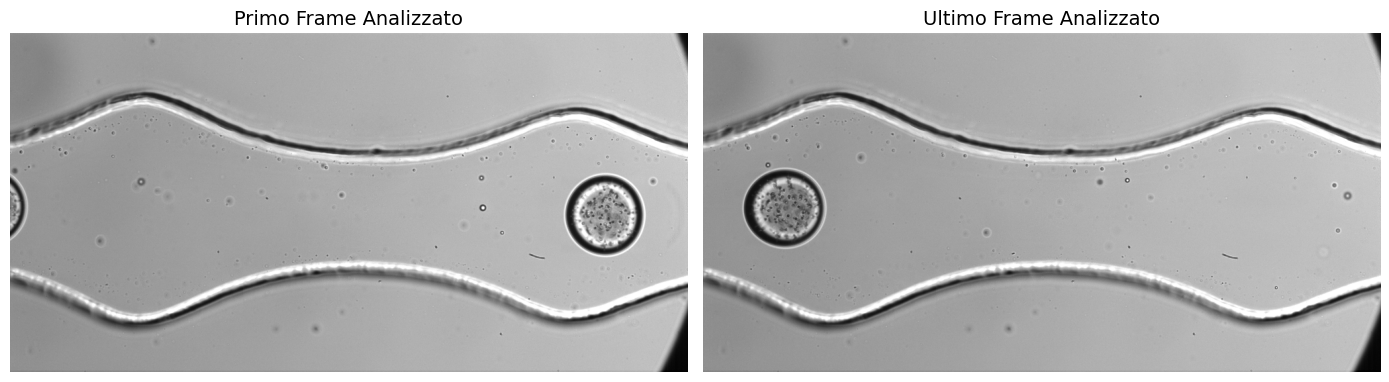

In [ ]:
# ----------------------------------------------------
# VISUALIZZAZIONE PRIMO E ULTIMO FRAME
# ----------------------------------------------------
import matplotlib.pyplot as plt
from skimage import io

primo_frame_path = selected_frames[0]
ultimo_frame_path = selected_frames[-1]

img_primo = io.imread(primo_frame_path)
img_ultimo = io.imread(ultimo_frame_path)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.imshow(img_primo, cmap="gray")
ax1.set_title(f"Primo Frame Analizzato", fontsize=14)
ax1.axis("off")

ax2.imshow(img_ultimo, cmap="gray")
ax2.set_title(f"Ultimo Frame Analizzato", fontsize=14)
ax2.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------
# VISUALIZATION OF ALL THE ROI
# ----------------------------------------------------
"""
import math

roi_list = []
frame_titles = []

# Ripercorriamo velocemente le immagini analizzate
for i, img_path in enumerate(selected_frames):
    img = io.imread(img_path)
    
    # La funzione restituisce: trovato, centro, ROI, affidabilità
    found, center, ROI, confidence = track_droplet_template(img, template, threshold=0.60, plot_result=False)
    
    if found:
        roi_list.append(ROI)
        frame_titles.append(f"Frame {i+1}\n(Conf: {confidence:.2f})")
    else:
        print(f"Frame {i+1}: Goccia NON trovata (sotto threshold).")

num_rois = len(roi_list)

# Disegniamo la griglia se abbiamo trovato almeno una ROI
if num_rois > 0:
    cols = 5
    rows = math.ceil(num_rois / cols)
    
    # Creiamo la figura (ogni grafico sarà circa 3x3 pollici)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    
    if num_rois > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
        
    for i in range(num_rois):
        ax = axes[i]
        ax.imshow(roi_list[i], cmap='gray')
        ax.set_title(frame_titles[i], fontsize=10)
        ax.axis('off')  # Nascondiamo i numeri degli assi x e y per pulizia
        
    # Eliminiamo gli eventuali riquadri extra rimasti vuoti
    for i in range(num_rois, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna ROI trovata da poter visualizzare.")
"""


SyntaxError: incomplete input (3384125007.py, line 4)